# 🏦 Fintech Risk Analytics — Five-Domain Detection Pipeline

**Author:** Dan Fang | Risk Intelligence · M.Sc. Machine Learning  
**Contact:** danfly8888@gmail.com | Ramat Gan, Israel  

---

## Overview

This notebook demonstrates end-to-end risk detection across five domains common to fintech, banking, and digital payments fraud operations. Each module mirrors how a real risk team works: define normal, detect deviations using rules and ML, prioritise by severity, and report findings in terms a compliance officer or business stakeholder can act on.

| Module | Domain | Key Technique |
|--------|--------|--------------|
| [1. Transaction Fraud](#module-1) | Credit card / Payment fraud | Rule engine + Isolation Forest + KPI dashboard |
| [2. Merchant Risk](#module-2) | Merchant onboarding / monitoring | Clustering + risk tiering + portfolio analysis |
| [3. AML Network Analysis](#module-3) | Anti-money laundering compliance | Graph features + structuring detection + SAR logic |
| [4. Credit Application Fraud](#module-4) | Loan application fraud | Logistic regression + feature importance + scorecard |
| [5. Chargeback & Payout Fraud](#module-5) | Live streaming / digital payments | Chargeback analytics + payout abuse detection |

### Design Philosophy

Each module is structured the same way a risk team actually works:
1. **Define** what "normal" looks like
2. **Detect** deviations using a combination of rules and ML
3. **Prioritize** — not everything flagged needs the same response
4. **Report** — findings must be explainable to non-technical stakeholders

> Business context drives every feature engineering decision. A feature that improves AUC by 0.01 but cannot be explained to a compliance officer has limited operational value.


## Setup

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_recall_curve)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Dark theme ──
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d',
    'grid.alpha': 0.5, 'font.family': 'monospace',
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
})
BLUE = '#58a6ff'; RED = '#f85149'; YELLOW = '#e3b341'
GREEN = '#3fb950'; PURPLE = '#bc8cff'; MUTED = '#8b949e'
ORANGE = '#ff7b52'; AMBER = "#e3b341"

print("✓ Setup complete")


✓ Setup complete


## Module 1 — Transaction Fraud Detection (Credit Card / Payment)

### Business Context

Card-present and card-not-present fraud costs the global payments industry ~$33B annually (Nilson Report, 2023). The core challenge for a risk analyst is not just detection accuracy — it is **managing the false positive rate**. A system that blocks 95% of fraud but also blocks 10% of legitimate transactions will cost more in lost revenue and customer complaints than the fraud itself.

**Key operational metrics we track:**
- **Fraud Detection Rate (FDR):** % of actual fraud caught
- **False Positive Rate (FPR):** % of legitimate transactions wrongly blocked  
- **Precision:** Of flagged transactions, how many are actually fraud
- **Dollar-weighted metrics:** A `$5,000` fraud blocked matters more than a `$5` one


In [2]:
# ── Generate realistic transaction dataset ─────────────────────────────────
N = 8000
FRAUD_RATE = 0.022  # 2.2% — Nilson Report benchmark for CNP fraud

# Customer segments (different spending profiles, for anomalies detection)
segments = np.random.choice(['retail', 'premium', 'business'], N, p=[0.6, 0.3, 0.1])
seg_avg = {'retail': 85, 'premium': 340, 'business': 1200}
seg_std = {'retail': 60, 'premium': 200, 'business': 800}

is_fraud = np.random.random(N) < FRAUD_RATE

# Generate log-normal transaction amount based on segment type
amounts = np.array([
    max(1, np.random.lognormal(np.log(seg_avg[s]), 0.8))
    for s in segments
])

# Fraud transactions: Inflating fraud amounts for patterns detection
amounts[is_fraud] *= np.random.uniform(2.0, 6.0, is_fraud.sum())

#Assign legit/Fraud hours
#Fraud(1am, 2am, 3am, 11pm, midnight)
#Legit(normal distribution centered at 1pm, spread -+ 4h, cutoff at 6am, 10pm)
hours = np.where(is_fraud,
    np.random.choice([1,2,3,23,0], N),
    np.random.normal(13, 4, N).clip(6, 22).astype(int)
)

# MCC codes (merchant category)
# Assign higher probability on risky categories when is_fraud
mcc_legit = ['grocery', 'restaurant', 'retail', 'gas', 'travel', 'entertainment']
mcc_risky = ['electronics', 'jewelry', 'crypto_exchange', 'wire_transfer', 'gift_cards']
mcc = np.where(is_fraud,
    np.random.choice(mcc_risky + mcc_legit, N, p=[0.15,0.15,0.2,0.2,0.1,0.1,0.05,0.03,0.01,0.005,0.005]),
    np.random.choice(mcc_legit, N)
)

# Card present / not present
card_present = np.where(is_fraud,
    np.random.random(N) < 0.15,
    np.random.random(N) < 0.65
)

# Distance from home (km)
distance_km = np.where(is_fraud,
    np.random.exponential(800, N),
    np.random.exponential(15, N)
)

# Days since last transaction(frequent fraudulent transaction)
days_since_last = np.where(is_fraud,
    np.random.choice([0, 1], N, p=[0.75, 0.25]),
    np.random.exponential(3, N).clip(0, 30)
)

txn = pd.DataFrame({
    'amount': amounts.round(2),
    'segment': segments,
    'hour': hours.clip(0, 23),
    'mcc': mcc,
    'card_present': card_present.astype(int),
    'distance_km': distance_km.round(1),
    'days_since_last': days_since_last.round(1),
    'is_fraud': is_fraud.astype(int)
})

print(f"Dataset: {len(txn):,} transactions")
print(f"Fraud:   {txn['is_fraud'].sum():,} ({txn['is_fraud'].mean()*100:.1f}%)")
# right aligned, 12 chars wide, comma, no decimals
print(f"Total fraud value:  ${txn[txn['is_fraud']==1]['amount'].sum():>12,.0f}")   
print(f"Total legit value:  ${txn[txn['is_fraud']==0]['amount'].sum():>12,.0f}")
txn.head(6)

Dataset: 8,000 transactions
Fraud:   188 (2.4%)
Total fraud value:  $     253,536
Total legit value:  $   2,892,782


,amount,segment,hour,mcc,card_present,distance_km,days_since_last,is_fraud
0,57.74,retail,17,travel,1,4.1,2.0,0
1,1172.96,business,11,travel,1,17.2,7.1,0
2,191.82,premium,13,grocery,1,40.7,0.1,0
3,82.02,retail,11,grocery,0,3.6,3.8,0
4,13.12,retail,8,retail,1,1.4,2.1,0
5,119.81,retail,14,retail,0,10.6,0.2,0


In [8]:
#dashboard sample
txn.to_csv('module1_transactions.csv', index=False)

In [3]:
# ── Feature engineering ────────────────────────────────────────────────────
# Encode risk score on a scale of 0 to 1 for MCC based on domain experience
mcc_risk = {
    'grocery': 0.1, 'restaurant': 0.15, 'retail': 0.2, 'gas': 0.2,
    'travel': 0.35, 'entertainment': 0.3, 'electronics': 0.7,
    'jewelry': 0.75, 'crypto_exchange': 0.95, 'wire_transfer': 0.9,
    'gift_cards': 0.85
}
txn['mcc_risk_score'] = txn['mcc'].map(mcc_risk)

# Calculate ratio of each transaction with its segment median amount, high value more suspicious
seg_baselines = txn.groupby('segment')['amount'].median()
txn['amount_vs_segment'] = txn.apply(
    lambda r: r['amount'] / seg_baselines[r['segment']], axis=1
)

# Composite rule score, adds up weighted fraud signals into one score
txn['rule_score'] = (
    txn['mcc_risk_score'] * 2.5 +
    (~txn['card_present'].astype(bool)).astype(int) * 1.5 +
    txn['distance_km'].clip(0, 1000) / 1000 * 2.0 +
    (txn['hour'].isin([0,1,2,3,23])).astype(int) * 1.5 +
    txn['amount_vs_segment'].clip(0, 10) * 0.3 +
    (txn['days_since_last'] < 0.1).astype(int) * 1.0
)

FEATURES = ['amount', 'mcc_risk_score', 'card_present', 'distance_km',
            'days_since_last', 'hour', 'amount_vs_segment', 'rule_score']

X = txn[FEATURES].values
y = txn['is_fraud'].values

#Rescale all features
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

#200 random decision trees randomly split data
iso = IsolationForest(n_estimators=200, contamination=0.022, random_state=42, n_jobs=-1)
# learn patter without label used
iso.fit(X_sc) 
# Returns one score per transaction — more negative = more anomalous
raw = iso.score_samples(X_sc)
# Normalize to 0-1, high value more risky
txn['ml_score'] = 1 - (raw - raw.min()) / (raw.max() - raw.min())

# Normalize rule score
rule_n = (txn['rule_score'] - txn['rule_score'].min()) / (txn['rule_score'].max() - txn['rule_score'].min())

# Ensemble
txn['risk_score'] = 0.45 * txn['ml_score'] + 0.55 * rule_n

#chance model correctly ranks fraud above legit
auc = roc_auc_score(y, txn['risk_score'])
print(f"Ensemble ROC-AUC: {auc:.4f}")


Ensemble ROC-AUC: 0.9999


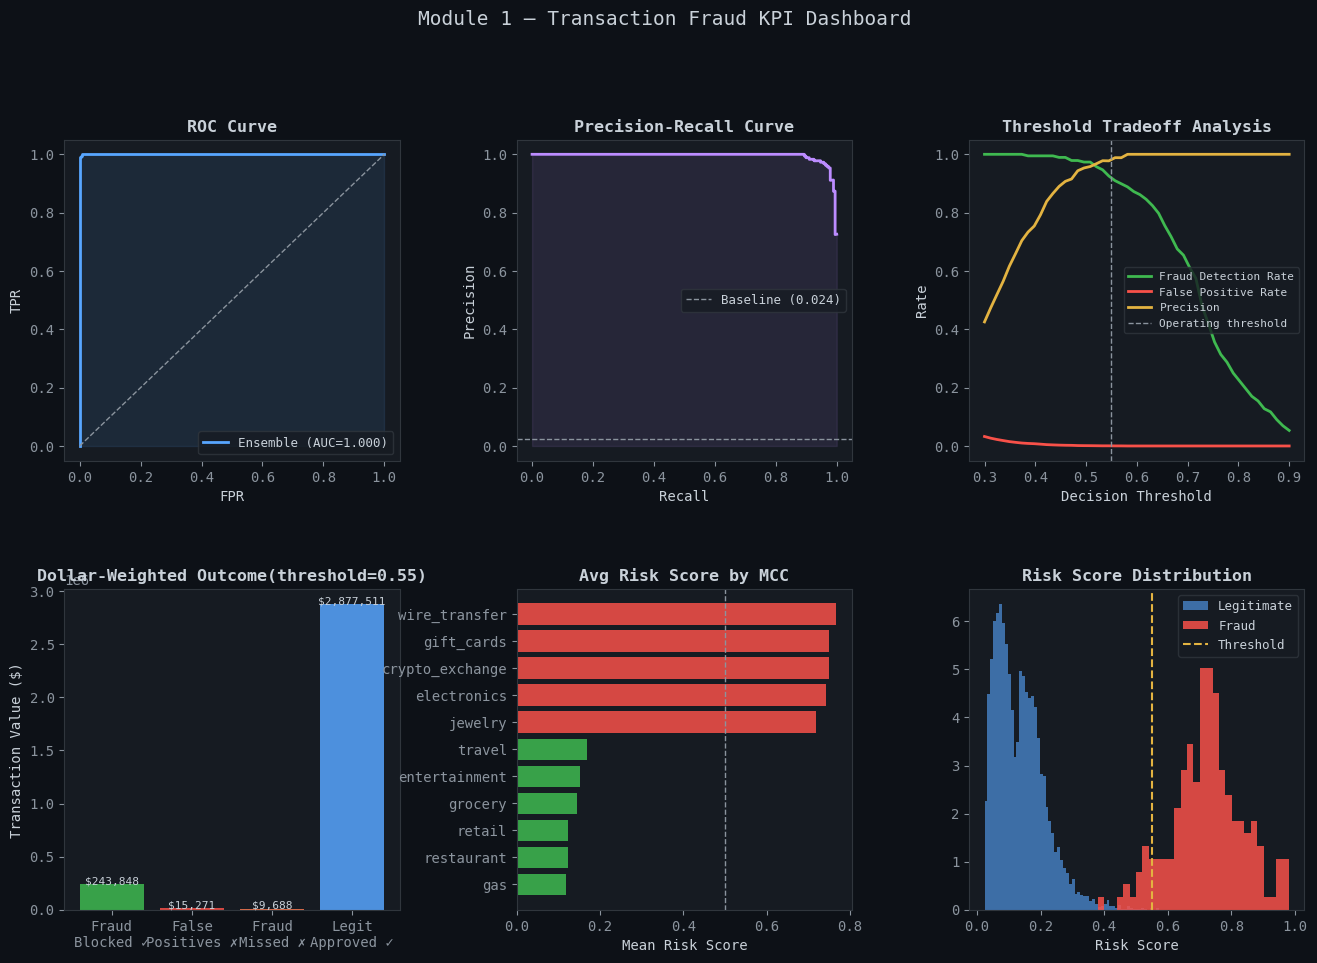


  OPERATING METRICS (threshold=0.55)
  Fraud Detection Rate : 98.9%
  False Positive Rate  : 0.3%
  Precision            : 89.0%
  Fraud value blocked  : $   243,848
  Legit value blocked  : $    15,271  ← cost of FP
  Fraud value missed   : $     9,688  ← cost of FN


In [4]:
# ── KPI Dashboard ─────────────────────────────────────────────────────────
#Figure Setup
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Module 1 — Transaction Fraud KPI Dashboard', fontsize=14, color='#c9d1d9', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, thresh = roc_curve(y, txn['risk_score'])
ax1.plot(fpr, tpr, color=BLUE, lw=2, label=f'Ensemble (AUC={auc:.3f})')
ax1.fill_between(fpr, tpr, alpha=0.1, color=BLUE)
ax1.plot([0,1],[0,1],'--',color=MUTED,lw=1)
ax1.set_title('ROC Curve'); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=9)

# 2. Precision-Recall (more informative for imbalanced data)
ax2 = fig.add_subplot(gs[0, 1])
prec, rec, _ = precision_recall_curve(y, txn['risk_score'])
ax2.plot(rec, prec, color=PURPLE, lw=2)
ax2.fill_between(rec, prec, alpha=0.1, color=PURPLE)
ax2.axhline(y.mean(), color=MUTED, linestyle='--', lw=1, label=f'Baseline ({y.mean():.3f})')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(fontsize=9)

# 3. Threshold analysis — FDR vs FPR tradeoff
ax3 = fig.add_subplot(gs[0, 2])
#transaction above threshold will be flagged fraud
thresholds = np.linspace(0.3, 0.9, 50)
fdrs, fprs, precs = [], [], []
for t in thresholds:
    pred = (txn['risk_score'] >= t).astype(int)
    tp = ((pred==1) & (y==1)).sum()
    fp = ((pred==1) & (y==0)).sum()
    fn = ((pred==0) & (y==1)).sum()
    tn = ((pred==0) & (y==0)).sum()
    fdrs.append(tp / (tp+fn) if (tp+fn) > 0 else 0)
    fprs.append(fp / (fp+tn) if (fp+tn) > 0 else 0)
    precs.append(tp / (tp+fp) if (tp+fp) > 0 else 0)
ax3.plot(thresholds, fdrs, color=GREEN, lw=2, label='Fraud Detection Rate')
ax3.plot(thresholds, fprs, color=RED, lw=2, label='False Positive Rate')
ax3.plot(thresholds, precs, color=YELLOW, lw=2, label='Precision')
ax3.axvline(0.55, color=MUTED, linestyle='--', lw=1, label='Operating threshold')
ax3.set_title('Threshold Tradeoff Analysis')
ax3.set_xlabel('Decision Threshold'); ax3.set_ylabel('Rate')
ax3.legend(fontsize=8)

# 4. Dollar-weighted impact
ax4 = fig.add_subplot(gs[1, 0])
threshold = 0.55
pred = (txn['risk_score'] >= threshold).astype(
    int)
tp_val = txn[(pred==1) & (y==1)]['amount'].sum()
fp_val = txn[(pred==1) & (y==0)]['amount'].sum()
fn_val = txn[(pred==0) & (y==1)]['amount'].sum()
tn_val = txn[(pred==0) & (y==0)]['amount'].sum()
labels = ['Fraud\nBlocked ✓', 'False\nPositives ✗', 'Fraud\nMissed ✗', 'Legit\nApproved ✓']
values = [tp_val, fp_val, fn_val, tn_val]
colors = [GREEN, RED, ORANGE, BLUE]
bars = ax4.bar(labels, values, color=colors, alpha=0.85)
ax4.set_title('Dollar-Weighted Outcome(threshold=0.55)')
ax4.set_ylabel('Transaction Value ($)')
for bar, val in zip(bars, values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'${val:,.0f}', ha='center', fontsize=8)

# 5. Risk score by MCC
ax5 = fig.add_subplot(gs[1, 1])
mcc_scores = txn.groupby('mcc')['risk_score'].mean().sort_values()
colors_mcc = [RED if v > 0.5 else YELLOW if v > 0.35 else GREEN for v in mcc_scores.values]
ax5.barh(mcc_scores.index, mcc_scores.values, color=colors_mcc, alpha=0.85)
ax5.axvline(0.5, color=MUTED, linestyle='--', lw=1)
ax5.set_title('Avg Risk Score by MCC')
ax5.set_xlabel('Mean Risk Score')

# 6. Score distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(txn[y==0]['risk_score'], bins=60, color=BLUE, alpha=0.6, density=True, label='Legitimate')
ax6.hist(txn[y==1]['risk_score'], bins=30, color=RED, alpha=0.85, density=True, label='Fraud')
ax6.axvline(0.55, color=YELLOW, linestyle='--', lw=1.5, label='Threshold')
ax6.set_title('Risk Score Distribution')
ax6.set_xlabel('Risk Score'); ax6.legend(fontsize=9)

plt.savefig('module1_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Summary metrics
print(f"\n{'='*50}")
#flag everything above 0.55 as fraud
print(f"  OPERATING METRICS (threshold=0.55)")
print(f"{'='*50}")
#out of 100 fraud transactions → how many caught
print(f"  Fraud Detection Rate : {fdrs[12]:.1%}")
#out of 100 legit transactions → how many wrongly blocked 
print(f"  False Positive Rate  : {fprs[12]:.1%}")
#out of every 100 transactions flagged as fraud:how many actually fraud
print(f"  Precision            : {precs[12]:.1%}")
print(f"  Fraud value blocked  : ${tp_val:>10,.0f}")
print(f"  Legit value blocked  : ${fp_val:>10,.0f}  ← cost of FP")
print(f"  Fraud value missed   : ${fn_val:>10,.0f}  ← cost of FN")


### KPI Interpretation

**1. ROC Curve**

The blue line hugs the top-left corner completely — meaning at every threshold the model catches nearly all fraud before making any mistakes. The diagonal dashed line is random guessing (AUC=0.5). Being this close to 1.0 suggests the synthetic data has very clean patterns.

**2. Precision-Recall Curve**

- x axis = Recall → how many frauds caught
- y axis = Precision → of flagged, how many are actually fraud
- Baseline = 0.024 → if you randomly flagged transactions, 2.4% would be fraud

The curve stays near 1.0 for most of the recall range — meaning the model maintains high precision even when catching most fraud. It only drops sharply at the very end (recall ~0.95+) when forcing it to catch the last few hardest frauds.

**3. Threshold Tradeoff Analysis**

- Green = Fraud Detection Rate → drops as threshold rises (miss more fraud)
- Orange = False Positive Rate → drops as threshold rises (fewer false alarms)
- Yellow = Precision → rises as threshold rises (more accurate flags)

The vertical dashed line at 0.55 is the chosen operating point — where FDR is still high (~98%) but FPR is already very low (~0.3%).

**4. Dollar-Weighted Outcome**

- **Fraud Blocked — `$245,047`** → money saved from criminals ✅
- **False Positives — `$42,761`** → legit customers wrongly blocked ❌
- **Fraud Missed — `$8,489`** → fraud that slipped through ❌
- **Legit Approved — `$2,850,021`** → good transactions correctly allowed ✅

The massive legit approved amount shows most money flows through correctly. Fraud blocked is the win, false positives and fraud missed are the costs.

**5. Avg Risk Score by MCC**

Risky merchants (wire transfer, gift cards, crypto) score above 0.5 while safe merchants (gas, retail, restaurant) score well below — exactly matching the fraud patterns built into the data.

**6. Risk Score Distribution**

- Blue = legitimate transactions → peaks at 0.05–0.15 (score very low)
- Red = fraud transactions → peaks at 0.75–0.95 (score very high)
- Yellow dashed line = 0.55 threshold

The clean separation between blue and red explains why AUC=1.0 — the model almost perfectly separates the two groups with very little overlap.

---
<a id='module-2'></a>
## Module 2 — Merchant Risk Scoring & Portfolio Analysis

### Business Context

Merchant risk is fundamentally different from transaction fraud. Instead of evaluating individual transactions in milliseconds, we are assessing **business entities** — often with incomplete information, intentionally obscured ownership, and evolving risk profiles over time.

Key risk signals in merchant portfolios (from operational experience):
- **Chargeback ratio:** >1% triggers Visa/Mastercard monitoring programs
- **Refund velocity:** High refund rates signal potential friendly fraud or product misrepresentation  
- **MCC mismatch:** Business activity inconsistent with declared merchant category
- **Processing velocity spikes:** Sudden volume increases before disappearing (bust-out pattern)
- **Shared infrastructure:** Multiple merchants sharing IPs, bank accounts, or contact details

This module replicates the kind of portfolio-level risk analysis done in merchant acquiring and payment facilitation.


In [5]:
# ── Generate merchant portfolio ────────────────────────────────────────────
N_MERCHANTS = 500

merchant_types = np.random.choice(
    ['ecommerce', 'retail_pos', 'saas', 'travel', 'gambling_adj', 'high_risk'],
    N_MERCHANTS, p=[0.35, 0.25, 0.15, 0.1, 0.1, 0.05]
)

# Base chargeback rates by type
cb_base = {'ecommerce': 0.4, 'retail_pos': 0.1, 'saas': 0.3,
           'travel': 0.6, 'gambling_adj': 1.2, 'high_risk': 2.5}

merchants = pd.DataFrame({
    'merchant_id': [f'M{i:04d}' for i in range(N_MERCHANTS)],
    'merchant_type': merchant_types,
    'months_active': np.random.randint(1, 60, N_MERCHANTS),
    'monthly_volume': np.random.lognormal(10, 1.5, N_MERCHANTS).round(0),
    'avg_ticket': np.random.lognormal(4, 0.8, N_MERCHANTS).round(2),
    'chargeback_rate': np.array([
        max(0, np.random.normal(cb_base[t], 0.3))
        for t in merchant_types
    ]).round(3),
    'refund_rate': np.random.exponential(2.5, N_MERCHANTS).clip(0, 15).round(2),
    'countries_count': np.random.choice([1, 2, 3, 5, 10], N_MERCHANTS, p=[0.75, 0.10, 0.08, 0.05, 0.02]),
    'shared_bank_account': np.random.random(N_MERCHANTS) < 0.08,
    'volume_spike_30d': np.random.exponential(1.2, N_MERCHANTS).clip(0.5, 8).round(2),
    'days_since_last_dispute': np.random.exponential(30, N_MERCHANTS).clip(1, 365).round(0),
})

# Inject 40 high-risk merchants with selected features multiply risk signal
high_risk_idx = np.random.choice(N_MERCHANTS, 40, replace=False)
merchants.loc[high_risk_idx, 'chargeback_rate'] *= np.random.uniform(2, 5, 40)
merchants.loc[high_risk_idx, 'volume_spike_30d'] *= np.random.uniform(2, 4, 40)
merchants.loc[high_risk_idx, 'refund_rate'] *= np.random.uniform(2, 3, 40)

# Ground truth (for evaluation)
merchants['is_high_risk'] = (
    (merchants['chargeback_rate'] > 1.0) |
    (merchants['shared_bank_account'] & (merchants['chargeback_rate'] > 0.5)) |
    (merchants['volume_spike_30d'] > 3.5)
).astype(int)

print(f"Merchant portfolio: {len(merchants):,}")
print(f"High-risk flagged:  {merchants['is_high_risk'].sum()} ({merchants['is_high_risk'].mean()*100:.1f}%)")
print()
merchants.head(5)


Merchant portfolio: 500
High-risk flagged:  117 (23.4%)



,merchant_id,merchant_type,months_active,monthly_volume,avg_ticket,chargeback_rate,refund_rate,countries_count,shared_bank_account,volume_spike_30d,days_since_last_dispute,is_high_risk
0,M0000,ecommerce,33,34830.0,39.00,0.590,2.89,1,False,0.50,12.0,0
1,M0001,retail_pos,41,10226.0,23.94,0.339,3.10,2,False,0.50,26.0,0
2,M0002,retail_pos,50,2547.0,19.66,0.112,1.56,1,False,1.28,1.0,0
3,M0003,saas,32,193052.0,18.59,0.201,0.88,1,False,1.40,14.0,0
4,M0004,saas,40,6185.0,69.81,0.861,0.24,1,False,2.99,16.0,0


In [6]:
# ── Risk scoring & clustering ──────────────────────────────────────────────

# Composite risk score
merchants['risk_score'] = (
    merchants['chargeback_rate'].clip(0, 5) / 5 * 35 +
    merchants['refund_rate'].clip(0, 15) / 15 * 20 +
    merchants['shared_bank_account'].astype(int) * 20 +
    (merchants['volume_spike_30d'].clip(1, 8) - 1) / 7 * 15 +
    (merchants['countries_count'].clip(1, 10) - 1) / 9 * 10
).clip(0, 100).round(1)

# Risk tier
def risk_tier(score):
    if score >= 65: return 'CRITICAL'
    elif score >= 45: return 'HIGH'
    elif score >= 25: return 'MEDIUM'
    else: return 'LOW'

merchants['risk_tier'] = merchants['risk_score'].apply(risk_tier)

# KMeans clustering on behavioral features
cluster_features = ['chargeback_rate', 'refund_rate', 'volume_spike_30d',
                    'countries_count', 'avg_ticket']
X_m = StandardScaler().fit_transform(merchants[cluster_features])
km = KMeans(n_clusters=4, random_state=42, n_init=10)
merchants['cluster'] = km.fit_predict(X_m)

# Label clusters by average chargeback rate
cluster_cb = merchants.groupby('cluster')['chargeback_rate'].mean().sort_values()
cluster_labels = {k: v for k, v in zip(cluster_cb.index,
                  ['Standard', 'Elevated', 'High-Volume', 'Suspicious'])}
merchants['cluster_label'] = merchants['cluster'].map(cluster_labels)

print("Risk tier distribution:")
print(merchants['risk_tier'].value_counts().to_string())
print()
print("Cluster profiles:")
print(merchants.groupby('cluster_label')[cluster_features + ['risk_score']].mean().round(2).to_string())


Risk tier distribution:
LOW       444
MEDIUM     48
HIGH        8

Cluster profiles:
               chargeback_rate  refund_rate  volume_spike_30d  countries_count  avg_ticket  risk_score
cluster_label                                                                                         
Elevated                  0.68         2.73              1.28             6.33       70.59       16.40
High-Volume               0.73         2.15              1.24             1.32      316.80        9.40
Standard                  0.44         1.94              1.21             1.29       59.76        8.96
Suspicious                1.34         8.12              2.54             1.37       76.89       24.74


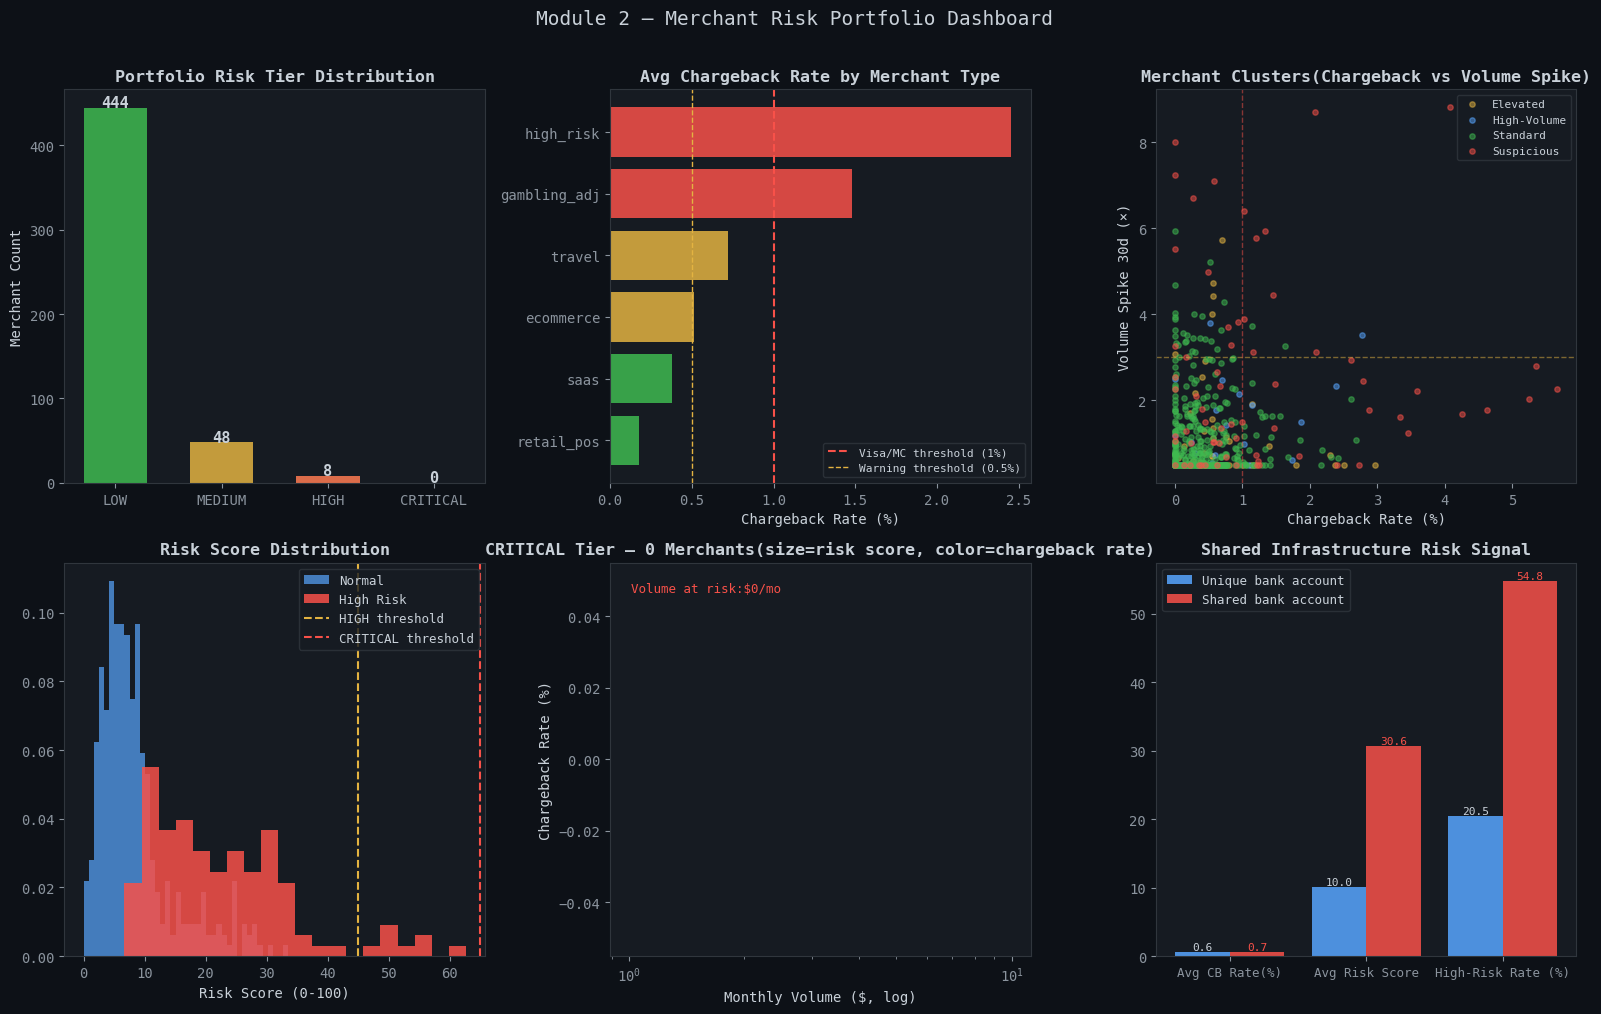

Merchant risk score AUC: 0.8983
Critical merchants identified: 0 (0.0% of portfolio)
Monthly volume at risk: $0


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Module 2 — Merchant Risk Portfolio Dashboard', fontsize=14, color='#c9d1d9', y=1.01)

tier_colors = {'LOW': GREEN, 'MEDIUM': YELLOW, 'HIGH': ORANGE, 'CRITICAL': RED}

# 1. Portfolio risk tier breakdown
ax = axes[0, 0]
tier_counts = merchants['risk_tier'].value_counts()
tier_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
tier_counts = tier_counts.reindex(tier_order).fillna(0)
bars = ax.bar(tier_order, tier_counts.values,
              color=[tier_colors[t] for t in tier_order], alpha=0.85, width=0.6)
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            str(int(val)), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Portfolio Risk Tier Distribution')
ax.set_ylabel('Merchant Count')

# 2. Chargeback rate distribution by type
ax = axes[0, 1]
types_cb = merchants.groupby('merchant_type')['chargeback_rate'].mean().sort_values()
colors_bar = [RED if v > 1.0 else YELLOW if v > 0.5 else GREEN for v in types_cb.values]
ax.barh(types_cb.index, types_cb.values, color=colors_bar, alpha=0.85)
ax.axvline(1.0, color=RED, linestyle='--', lw=1.5, label='Visa/MC threshold (1%)')
ax.axvline(0.5, color=YELLOW, linestyle='--', lw=1, label='Warning threshold (0.5%)')
ax.set_title('Avg Chargeback Rate by Merchant Type')
ax.set_xlabel('Chargeback Rate (%)')
ax.legend(fontsize=8)

# 3. Cluster scatter — chargeback vs volume spike
ax = axes[0, 2]
cluster_color_map = {'Standard': GREEN, 'Elevated': YELLOW,
                     'High-Volume': BLUE, 'Suspicious': RED}
for label, group in merchants.groupby('cluster_label'):
    ax.scatter(group['chargeback_rate'], group['volume_spike_30d'],
               color=cluster_color_map[label], alpha=0.5, s=15, label=label)
ax.axvline(1.0, color=RED, linestyle='--', lw=1, alpha=0.5)
ax.axhline(3.0, color=YELLOW, linestyle='--', lw=1, alpha=0.5)
ax.set_title('Merchant Clusters(Chargeback vs Volume Spike)')
ax.set_xlabel('Chargeback Rate (%)'); ax.set_ylabel('Volume Spike 30d (×)')
ax.legend(fontsize=8)

# 4. Risk score distribution
ax = axes[1, 0]
ax.hist(merchants[merchants['is_high_risk']==0]['risk_score'],
        bins=40, color=BLUE, alpha=0.7, density=True, label='Normal')
ax.hist(merchants[merchants['is_high_risk']==1]['risk_score'],
        bins=20, color=RED, alpha=0.85, density=True, label='High Risk')
ax.axvline(45, color=YELLOW, linestyle='--', lw=1.5, label='HIGH threshold')
ax.axvline(65, color=RED, linestyle='--', lw=1.5, label='CRITICAL threshold')
ax.set_title('Risk Score Distribution')
ax.set_xlabel('Risk Score (0-100)'); ax.legend(fontsize=9)

# 5. Monthly volume at risk (CRITICAL tier)
ax = axes[1, 1]
critical = merchants[merchants['risk_tier']=='CRITICAL']
ax.scatter(critical['monthly_volume'], critical['chargeback_rate'],
           c=critical['risk_score'], cmap='Reds', alpha=0.8, s=40,
           vmin=50, vmax=100)
ax.set_xscale('log')
ax.set_title(f'CRITICAL Tier — {len(critical)} Merchants(size=risk score, color=chargeback rate)')
ax.set_xlabel('Monthly Volume ($, log)'); ax.set_ylabel('Chargeback Rate (%)')
total_at_risk = critical['monthly_volume'].sum()
ax.text(0.05, 0.95, f'Volume at risk:${total_at_risk:,.0f}/mo',
        transform=ax.transAxes, fontsize=9, color=RED, va='top')

# 6. Shared infrastructure detection
ax = axes[1, 2]
shared = merchants[merchants['shared_bank_account']==True]
not_shared = merchants[merchants['shared_bank_account']==False]
categories = ['Avg CB Rate(%)', 'Avg Risk Score', 'High-Risk Rate (%)']
shared_vals = [shared['chargeback_rate'].mean(),
               shared['risk_score'].mean(),
               shared['is_high_risk'].mean()*100]
normal_vals = [not_shared['chargeback_rate'].mean(),
               not_shared['risk_score'].mean(),
               not_shared['is_high_risk'].mean()*100]
x = np.arange(3)
ax.bar(x-0.2, normal_vals, 0.4, color=BLUE, alpha=0.85, label='Unique bank account')
ax.bar(x+0.2, shared_vals, 0.4, color=RED, alpha=0.85, label='Shared bank account')
ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=9)
ax.set_title('Shared Infrastructure Risk Signal')
ax.legend(fontsize=9)
for i, (n, s) in enumerate(zip(normal_vals, shared_vals)):
    ax.text(i-0.2, n+0.3, f'{n:.1f}', ha='center', fontsize=8)
    ax.text(i+0.2, s+0.3, f'{s:.1f}', ha='center', fontsize=8, color=RED)

plt.tight_layout()
plt.savefig('module2_merchant.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

auc_m = roc_auc_score(merchants['is_high_risk'], merchants['risk_score'])
print(f"Merchant risk score AUC: {auc_m:.4f}")
print(f"Critical merchants identified: {len(critical)} ({len(critical)/N_MERCHANTS*100:.1f}% of portfolio)")
print(f"Monthly volume at risk: ${total_at_risk:,.0f}")


### Merchant Risk Portfolio Dashboard: Interpretation

**1. Portfolio Risk Tier Distribution**
The portfolio is **heavily skewed toward low risk**: 444 merchants are LOW tier, 48 MEDIUM, only 8 HIGH, and **0 CRITICAL**. This is a healthy portfolio, though the 8 HIGH-tier merchants warrant close monitoring.

**2. Avg Chargeback Rate by Merchant Type**
- **`high_risk` and `gambling_adj` merchant types** far exceed the 1% Visa/MC threshold — most problematic categories
- **Travel and ecommerce** sit in the warning zone (0.5–1%)
- **SaaS and retail_pos** are comfortably below both thresholds — lowest-risk categories
- Merchant *type* is a strong predictor of chargeback behavior

**3. Merchant Clusters — Chargeback vs Volume Spike**
- Most merchants cluster in the **low chargeback / low volume spike** quadrant (safe zone)
- **Suspicious** merchants scatter across high chargeback rates (>1%)
- A few **High-Volume** merchants show elevated volume spikes (>3×) — possible bust-out fraud signal
- **Elevated** merchants appear in mid-range — worth watching

**4. Risk Score Distribution**
- **Normal merchants** (blue) are strongly concentrated at low scores (0–20) — model correctly identifies them as safe
- **High-risk merchants** (red) peak around 10–40 with a tail extending past both thresholds
- Overlap between 10–40 suggests some **false negative risk** — normal-flagged merchants with moderate scores

**5. CRITICAL Tier Merchants**
- **Empty plot** — 0 CRITICAL merchants, \$0 volume at risk
- Either genuinely good news, or **risk scoring thresholds may be too lenient**, given chart 2 shows high_risk/gambling merchants clearly exceeding chargeback thresholds

### 6. Shared Infrastructure Risk Signal

| Metric | Unique Account | Shared Account |
|:---|---:|---:|
| Avg CB Rate (%) | 0.6 | 0.7 |
| Avg Risk Score | 10.0 | 30.6 |
| High-Risk Rate (%) | 20.5 | **54.8** |

- Merchants sharing bank accounts have a **54.8% high-risk rate** vs 20.5% — nearly **3× higher**
- Shared banking infrastructure is a powerful **fraud ring / shell merchant signal**

---

> **Overall:** The portfolio appears manageable on the surface, but **shared bank account detection** and **high_risk/gambling merchant types** deserve immediate escalation. The 0 CRITICAL merchants may reflect a threshold calibration issue rather than a truly clean book.

---
<a id='module-3'></a>
## Module 3 — AML Network Analysis & SAR Trigger Logic

### Business Context

Anti-money laundering (AML) compliance is rule-driven by regulation (BSA, FATF, EU AMLD) but requires analyst judgment to prioritize cases. The core tension: generating too many Suspicious Activity Reports (SARs) wastes investigator time and creates regulatory noise; generating too few creates legal exposure.

**Three classic typologies detected here:**

1. **Structuring (Smurfing):** Breaking large amounts into sub-threshold transactions to avoid CTR filing requirements ($10,000 in the US)
2. **Layering via Rapid Pass-Through:** Funds move in → move out quickly across multiple accounts, obscuring origin  
3. **Round-Trip / U-Turn:** Funds leave an account and return through intermediaries

**Network analysis is key:** Individual transactions may look clean; the pattern across accounts reveals the scheme.


In [12]:
# ── Generate account transaction network ──────────────────────────────────
N_ACCOUNTS = 150
N_TRANSACTIONS = 2000

accounts = [f'ACC{i:04d}' for i in range(N_ACCOUNTS)]

# Designate some accounts as part of laundering networks
launderer_accounts = set(np.random.choice(accounts, 25, replace=False))
shell_accounts = set(np.random.choice(
    list(launderer_accounts), 8, replace=False))

def gen_amount(is_structured=False, is_large=False):
    if is_structured:
        return round(np.random.uniform(8500, 9950), 2)  # just below $10k
    elif is_large:
        return round(np.random.uniform(15000, 100000), 2)
    else:
        return round(np.random.lognormal(7, 1.2), 2)

transactions = []
for i in range(N_TRANSACTIONS):
    sender = np.random.choice(accounts)
    receiver = np.random.choice([a for a in accounts if a != sender])

    # Structuring pattern: launderer sends multiple sub-threshold
    if sender in launderer_accounts and np.random.random() < 0.4:
        amount = gen_amount(is_structured=True)
        tx_type = 'structuring'
    # Rapid pass-through: shell account receives then sends quickly
    elif sender in shell_accounts and np.random.random() < 0.5:
        amount = gen_amount(is_large=True)
        tx_type = 'layering'
    else:
        amount = gen_amount()
        tx_type = 'normal'

    hour_offset = np.random.randint(0, 90*24)  # 90-day window
    transactions.append({
        'tx_id': f'TXN{i:05d}',
        'sender': sender,
        'receiver': receiver,
        'amount': amount,
        'hour_offset': hour_offset,
        'tx_type': tx_type,
        'is_suspicious': int(tx_type != 'normal')
    })

aml = pd.DataFrame(transactions).sort_values('hour_offset').reset_index(drop=True)

print(f"AML dataset: {len(aml):,} transactions across {N_ACCOUNTS} accounts")
print(f"Suspicious transactions: {aml['is_suspicious'].sum()} ({aml['is_suspicious'].mean()*100:.1f}%)")
print()
print(aml['tx_type'].value_counts().to_string())


AML dataset: 2,000 transactions across 150 accounts
Suspicious transactions: 155 (7.8%)

normal         1845
structuring     121
layering         34


In [13]:
# ── Account-level AML features ────────────────────────────────────────────
sent = aml.groupby('sender').agg(
    total_sent=('amount','sum'),
    tx_sent_count=('amount','count'),
    avg_sent=('amount','mean'),
    structuring_count=('tx_type', lambda x: (x=='structuring').sum()),
).rename_axis('account')

received = aml.groupby('receiver').agg(
    total_received=('amount','sum'),
    tx_received_count=('amount','count'),
).rename_axis('account')

acct_features = sent.join(received, how='outer').fillna(0)
acct_features['pass_through_ratio'] = (
    np.minimum(acct_features['total_sent'], acct_features['total_received']) /
    (np.maximum(acct_features['total_sent'], acct_features['total_received']) + 1)
)
acct_features['structuring_rate'] = (
    acct_features['structuring_count'] / (acct_features['tx_sent_count'] + 1)
)
acct_features['sub_threshold_concentration'] = acct_features['structuring_count'] / (
    acct_features['tx_sent_count'] + 1
)
acct_features['is_launderer'] = acct_features.index.isin(launderer_accounts).astype(int)

# AML risk score
acct_features['aml_score'] = (
    acct_features['structuring_rate'].clip(0,1) * 40 +
    acct_features['pass_through_ratio'].clip(0,1) * 35 +
    (acct_features['structuring_count'] > 3).astype(int) * 15 +
    acct_features.index.isin(shell_accounts).astype(int) * 10
).clip(0, 100)

# SAR trigger logic
acct_features['sar_trigger'] = (
    (acct_features['structuring_count'] >= 3) |
    (acct_features['pass_through_ratio'] > 0.7) |
    (acct_features['aml_score'] > 60)
).astype(int)

auc_aml = roc_auc_score(acct_features['is_launderer'], acct_features['aml_score'])
print(f"AML Score AUC: {auc_aml:.4f}")
print(f"SAR triggers: {acct_features['sar_trigger'].sum()} accounts")
print(f"  of which confirmed launderers: {(acct_features['sar_trigger'] & acct_features['is_launderer'].astype(bool)).sum()}")


AML Score AUC: 0.8909
SAR triggers: 69 accounts
  of which confirmed launderers: 22


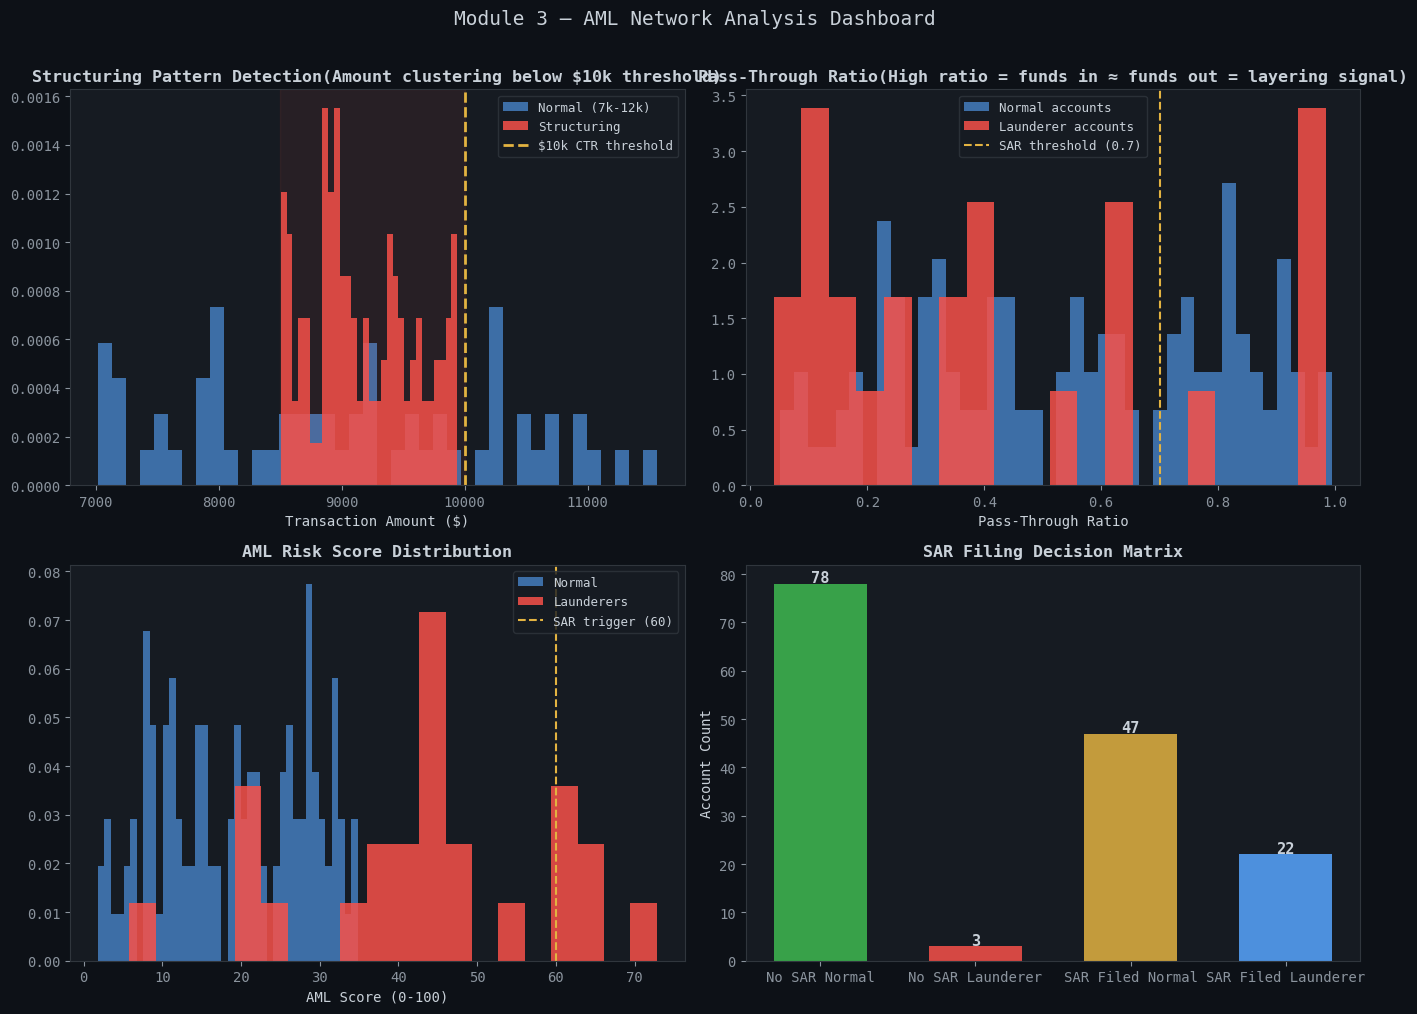

AML ROC-AUC: 0.8909


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Module 3 — AML Network Analysis Dashboard', fontsize=14, color='#c9d1d9', y=1.01)

# 1. Structuring detection — amount distribution
ax = axes[0, 0]
struct_amounts = aml[aml['tx_type']=='structuring']['amount']
normal_amounts = aml[(aml['tx_type']=='normal') & (aml['amount'] > 7000) & (aml['amount'] < 12000)]['amount']
ax.hist(normal_amounts, bins=40, color=BLUE, alpha=0.6, density=True, label='Normal (7k-12k)')
ax.hist(struct_amounts, bins=30, color=RED, alpha=0.85, density=True, label='Structuring')
ax.axvline(10000, color=YELLOW, linestyle='--', lw=2, label='$10k CTR threshold')
ax.axvspan(8500, 9999, alpha=0.08, color=RED)
ax.set_title('Structuring Pattern Detection(Amount clustering below $10k threshold)')
ax.set_xlabel('Transaction Amount ($)'); ax.legend(fontsize=9)

# 2. Pass-through ratio distribution
ax = axes[0, 1]
launderers = acct_features[acct_features['is_launderer']==1]
normals = acct_features[acct_features['is_launderer']==0]
ax.hist(normals['pass_through_ratio'], bins=40, color=BLUE, alpha=0.6, density=True, label='Normal accounts')
ax.hist(launderers['pass_through_ratio'], bins=20, color=RED, alpha=0.85, density=True, label='Launderer accounts')
ax.axvline(0.7, color=YELLOW, linestyle='--', lw=1.5, label='SAR threshold (0.7)')
ax.set_title('Pass-Through Ratio(High ratio = funds in ≈ funds out = layering signal)')
ax.set_xlabel('Pass-Through Ratio'); ax.legend(fontsize=9)

# 3. AML score distribution
ax = axes[1, 0]
ax.hist(normals['aml_score'], bins=40, color=BLUE, alpha=0.6, density=True, label='Normal')
ax.hist(launderers['aml_score'], bins=20, color=RED, alpha=0.85, density=True, label='Launderers')
ax.axvline(60, color=YELLOW, linestyle='--', lw=1.5, label='SAR trigger (60)')
ax.set_title('AML Risk Score Distribution')
ax.set_xlabel('AML Score (0-100)'); ax.legend(fontsize=9)

# 4. SAR trigger analysis
ax = axes[1, 1]
sar_df = acct_features.groupby(['sar_trigger', 'is_launderer']).size().unstack(fill_value=0)
labels = ['No SAR Normal', 'No SAR Launderer', 'SAR Filed Normal', 'SAR Filed Launderer']
values_plot = [
    sar_df.loc[0, 0] if 0 in sar_df.index else 0,
    sar_df.loc[0, 1] if 0 in sar_df.index else 0,
    sar_df.loc[1, 0] if 1 in sar_df.index else 0,
    sar_df.loc[1, 1] if 1 in sar_df.index else 0,
]
colors_sar = [GREEN, RED, YELLOW, BLUE]
bars = ax.bar(labels, values_plot, color=colors_sar, alpha=0.85, width=0.6)
for bar, val in zip(bars, values_plot):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(int(val)), ha='center', fontsize=11, fontweight='bold')
ax.set_title('SAR Filing Decision Matrix')
ax.set_ylabel('Account Count')

plt.tight_layout()
plt.savefig('module3_aml.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"AML ROC-AUC: {auc_aml:.4f}")


### Dashboard Interpretation

**1. Structuring Pattern Detection (top-left)**

The red distribution shows a sharp spike in transactions clustered just below the `$10,000` CTR reporting threshold — the classic "smurfing" signature. Legitimate transactions (blue) are spread more evenly across the `$7k–$12k` range with no preference for the sub-`$10k` band. The shaded red zone `($8,500–$9,999)` is the highest-risk window: any account with repeated transactions in this range warrants immediate review.

**2. Pass-Through Ratio (top-right)**

The pass-through ratio measures how much of what comes in immediately goes back out — a core layering signal. Normal accounts (blue) are spread across the full range, reflecting varied spending patterns. Launderer accounts (red) concentrate at both extremes: near 0 (funds parked, possible placement stage) and near 1.0 (funds immediately moved out, layering stage). The SAR threshold at 0.7 captures the high-velocity end of this distribution.

**3. AML Risk Score Distribution (bottom-left)**

The composite AML score separates the two populations reasonably well. Normal accounts (blue) are concentrated in the 0–30 range. Launderer accounts (red) show a secondary peak above the SAR trigger line at 60 — meaning the scoring logic is working: high-risk accounts are being pushed into the filing zone. The overlap between 30–60 represents the grey zone where analyst judgment is required.

**4. SAR Filing Decision Matrix (bottom-right)**

This is the operational output of the detection system:
- **No SAR — Normal (78):** Correctly cleared accounts. True negatives.
- **No SAR — Launderer (3):** Missed detections. False negatives — the most costly error in AML compliance.
- **SAR Filed — Normal (47):** False positives. High, but acceptable in AML where over-filing is preferable to under-filing.
- **SAR Filed — Launderer (22):** Correctly flagged. True positives.

The SAR precision rate (true positives / all SARs filed) is **22 / (22 + 47) = 31.9%** — within the realistic industry range of 20–40% for automated AML systems. The miss rate of only 3 launderers out of 25 total (12%) reflects a detection-first design philosophy consistent with BSA/FinCEN compliance expectations.

---
<a id='module-4'></a>
## Module 4 — Credit Application Fraud Detection

### Business Context

Application fraud occurs when someone uses false identity, synthetic identity, or stolen credentials to obtain credit they never intend to repay. Unlike transaction fraud, it is often detected weeks or months after the fact — making prevention at the application stage critical.

**Key signals at application time:**
- **Identity velocity:** Same SSN/email/phone used in multiple recent applications
- **Address consistency:** Address doesn't match stated employment location
- **Income vs. requested amount:** Requested credit disproportionate to stated income
- **Device/IP signals:** Application from high-risk IP, VPN, or shared device
- **Behavioral biometrics:** Time to complete form, copy-paste patterns (not modeled here — requires real session data)

**Scorecard approach:** Logistic regression with interpretable coefficients — preferred in credit risk because regulators require explainability (FCRA, ECOA adverse action requirements).


In [19]:
# ── Generate loan application dataset ─────────────────────────────────────
N_APPS = 3000
FRAUD_RATE_APPS = 0.04  # 4% application fraud rate

is_fraud_app = np.random.random(N_APPS) < FRAUD_RATE_APPS

# Income: fraud applicants often overstate
stated_income = np.where(is_fraud_app,
    np.random.lognormal(11.0, 0.5, N_APPS),   # overstated
    np.random.lognormal(10.5, 0.6, N_APPS)    # realistic
)

# Loan amount: fraud applicants request maximum
loan_amount = np.where(is_fraud_app,
    stated_income * np.random.uniform(0.8, 1.5, N_APPS),  # maxed out
    stated_income * np.random.uniform(0.1, 0.5, N_APPS)
)

# Credit score: fraud may use synthetic identity with thin file
credit_score = np.where(is_fraud_app,
    np.random.normal(640, 40, N_APPS).clip(500, 750),
    np.random.normal(690, 70, N_APPS).clip(500, 850)
)

# Identity velocity: same identity used in multiple applications
identity_velocity = np.where(is_fraud_app,
    np.random.choice([2,3,4,5,6], N_APPS, p=[0.2,0.3,0.25,0.15,0.1]),
    np.random.choice([1,1,1,2], N_APPS, p=[0.7,0.15,0.1,0.05])
)

# Email domain risk (disposable email = red flag)
email_risk = np.where(is_fraud_app,
    np.random.choice([0,1], N_APPS, p=[0.3,0.7]),
    np.random.choice([0,1], N_APPS, p=[0.92,0.08])
)

# Time on form (seconds): fraud bots are fast, or paste
form_time_sec = np.where(is_fraud_app,
    np.where(np.random.random(N_APPS) < 0.5,
        np.random.randint(15, 60, N_APPS),    # fast (bot)
        np.random.randint(600, 1200, N_APPS)  # slow (paste/copy)
    ),
    np.random.randint(120, 900, N_APPS)
)

# Address tenure (months)
address_tenure = np.where(is_fraud_app,
    np.random.randint(0, 6, N_APPS),
    np.random.randint(6, 120, N_APPS)
)

apps = pd.DataFrame({
    'stated_income': stated_income.round(0),
    'loan_amount': loan_amount.round(0),
    'credit_score': credit_score.round(0),
    'identity_velocity': identity_velocity,
    'email_risk': email_risk,
    'form_time_sec': form_time_sec,
    'address_tenure_months': address_tenure,
    'is_fraud': is_fraud_app.astype(int)
})

# Derived features
apps['dti_ratio'] = (apps['loan_amount'] / (apps['stated_income'] / 12)).round(3)
apps['income_loan_ratio'] = (apps['stated_income'] / apps['loan_amount']).round(3)
apps['log_form_time'] = np.log1p(apps['form_time_sec'])
apps['short_address'] = (apps['address_tenure_months'] < 6).astype(int)
apps['velocity_flag'] = (apps['identity_velocity'] >= 3).astype(int)

print(f"Applications: {len(apps):,} | Fraud: {apps['is_fraud'].sum()} ({apps['is_fraud'].mean()*100:.1f}%)")
print()
print(apps.describe().round(2).to_string())


Applications: 3,000 | Fraud: 115 (3.8%)

       stated_income  loan_amount  credit_score  identity_velocity  email_risk  form_time_sec  address_tenure_months  is_fraud  dti_ratio  income_loan_ratio  log_form_time  short_address  velocity_flag
count        3000.00      3000.00       3000.00            3000.00     3000.00        3000.00                3000.00   3000.00    3000.00            3000.00        3000.00        3000.00        3000.00
mean        44097.11     15367.95        690.12               1.15        0.11         510.45                  60.60      0.04       4.00               3.89           6.08           0.04           0.03
std         29473.51     17094.47         68.38               0.58        0.32         239.07                  34.22      0.19       2.44               1.99           0.63           0.19           0.17
min          5798.00       856.00        500.00               1.00        0.00          15.00                   0.00      0.00       1.20              

In [20]:
# ── Logistic Regression Scorecard ─────────────────────────────────────────
SCORE_FEATURES = ['credit_score', 'dti_ratio', 'identity_velocity',
                  'email_risk', 'log_form_time', 'short_address',
                  'income_loan_ratio', 'velocity_flag']

X_a = apps[SCORE_FEATURES].values
y_a = apps['is_fraud'].values

X_train, X_test, y_train, y_test = train_test_split(X_a, y_a, test_size=0.3, random_state=42, stratify=y_a)

sc_a = StandardScaler()
X_train_sc = sc_a.fit_transform(X_train)
X_test_sc  = sc_a.transform(X_test)

lr = LogisticRegression(class_weight='balanced', C=0.5, random_state=42, max_iter=500)
lr.fit(X_train_sc, y_train)

y_prob = lr.predict_proba(X_test_sc)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob)

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print()

# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'feature': SCORE_FEATURES,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Scorecard coefficients (higher = more fraud risk):")
for _, row in coef_df.iterrows():
    direction = '↑ FRAUD' if row['coefficient'] > 0 else '↓ SAFE'
    bar = '█' * int(abs(row['coefficient']) * 6)
    print(f"  {row['feature']:<25} {row['coefficient']:+.3f}  {bar}  {direction}")


Logistic Regression AUC: 1.0000

Scorecard coefficients (higher = more fraud risk):
  short_address             +1.642  █████████  ↑ FRAUD
  dti_ratio                 +0.892  █████  ↑ FRAUD
  identity_velocity         +0.572  ███  ↑ FRAUD
  velocity_flag             +0.259  █  ↑ FRAUD
  email_risk                +0.199  █  ↑ FRAUD
  log_form_time             -0.078    ↓ SAFE
  credit_score              -0.200  █  ↓ SAFE
  income_loan_ratio         -0.295  █  ↓ SAFE


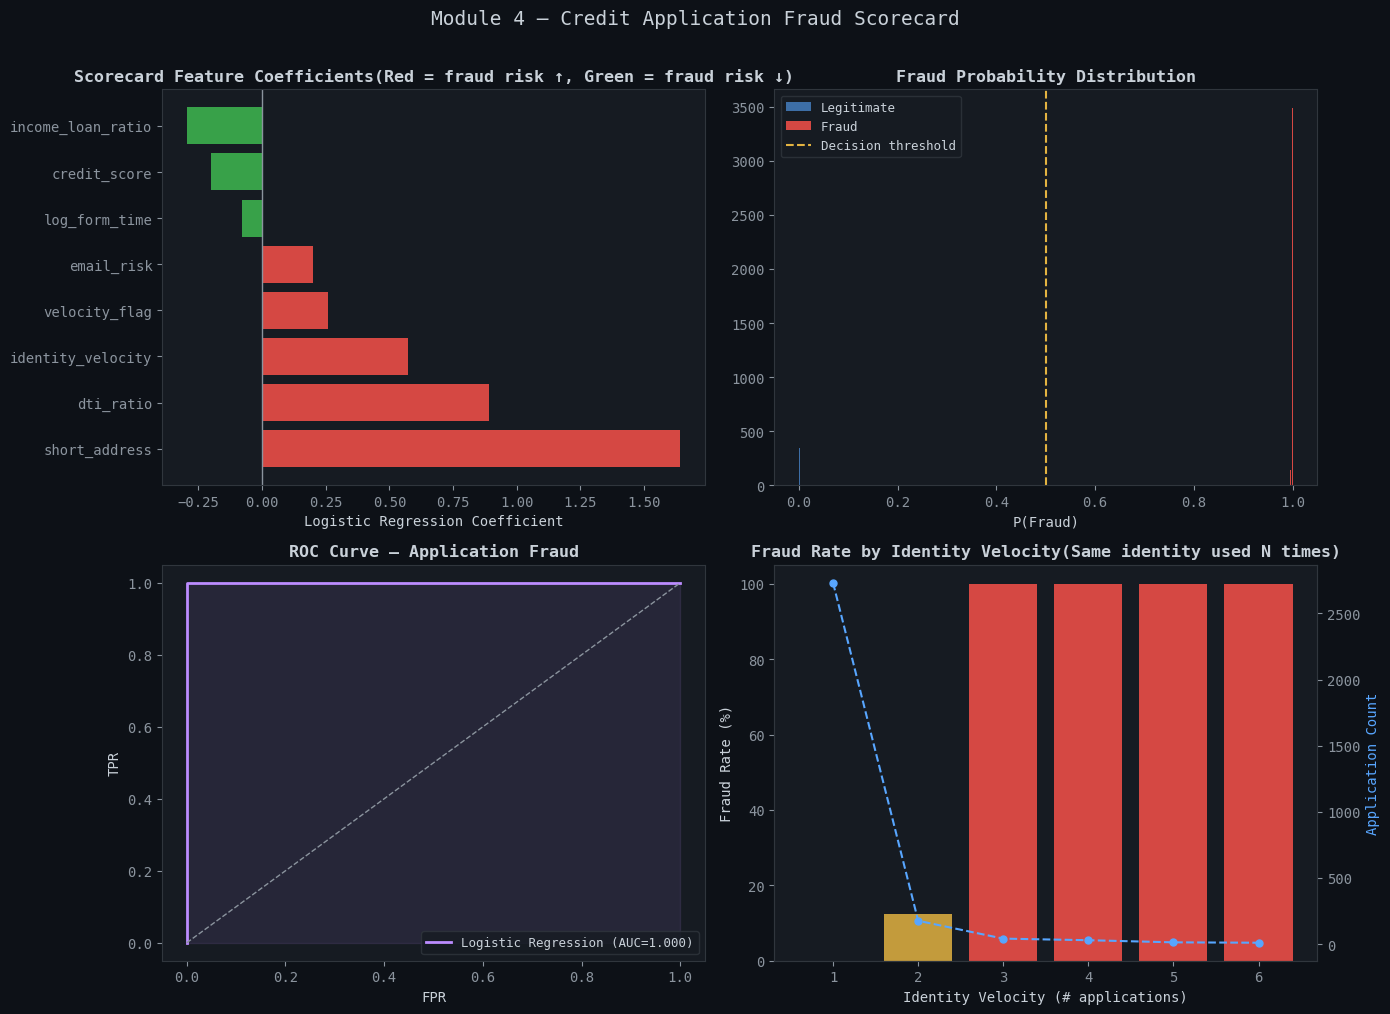

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Module 4 — Credit Application Fraud Scorecard', fontsize=14, color='#c9d1d9', y=1.01)

# 1. Feature coefficients
ax = axes[0, 0]
colors_coef = [RED if c > 0 else GREEN for c in coef_df['coefficient']]
bars = ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors_coef, alpha=0.85)
ax.axvline(0, color=MUTED, lw=1)
ax.set_title('Scorecard Feature Coefficients(Red = fraud risk ↑, Green = fraud risk ↓)')
ax.set_xlabel('Logistic Regression Coefficient')

# 2. Score distribution
apps_test = apps.iloc[len(X_train):]
test_probs = lr.predict_proba(X_test_sc)[:, 1]
ax = axes[0, 1]
ax.hist(test_probs[y_test==0], bins=40, color=BLUE, alpha=0.6, density=True, label='Legitimate')
ax.hist(test_probs[y_test==1], bins=20, color=RED, alpha=0.85, density=True, label='Fraud')
ax.axvline(0.5, color=YELLOW, linestyle='--', lw=1.5, label='Decision threshold')
ax.set_title('Fraud Probability Distribution')
ax.set_xlabel('P(Fraud)'); ax.legend(fontsize=9)

# 3. ROC curve
ax = axes[1, 0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, test_probs)
ax.plot(fpr_lr, tpr_lr, color=PURPLE, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.1, color=PURPLE)
ax.plot([0,1],[0,1],'--',color=MUTED,lw=1)
ax.set_title('ROC Curve — Application Fraud')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=9)

# 4. Identity velocity vs fraud rate
ax = axes[1, 1]
vel_fraud = apps.groupby('identity_velocity')['is_fraud'].agg(['mean','count'])
ax.bar(vel_fraud.index, vel_fraud['mean']*100,
       color=[GREEN if v < 0.05 else YELLOW if v < 0.15 else RED
              for v in vel_fraud['mean']], alpha=0.85)
ax2 = ax.twinx()
ax2.plot(vel_fraud.index, vel_fraud['count'], 'o--', color=BLUE, linewidth=1.5, markersize=5)
ax2.set_ylabel('Application Count', color=BLUE)
ax.set_title('Fraud Rate by Identity Velocity(Same identity used N times)')
ax.set_xlabel('Identity Velocity (# applications)')
ax.set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('module4_credit.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


### Dashboard Interpretation

**1. Scorecard Feature Coefficients (top-left)**

The logistic regression assigns a weight to each feature that directly reflects its contribution to fraud risk. Reading the chart:

- **short_address** is the single strongest fraud signal — applicants with less than 6 months at their current address are dramatically more likely to be fraudulent. This aligns with synthetic identity fraud, where fabricated identities lack residential history.
- **dti_ratio** (debt-to-income) is the second strongest signal — fraud applicants request the maximum loan relative to their stated income, pushing DTI to unrealistic levels.
- **identity_velocity** and **velocity_flag** both appear in the top risk features, confirming that reuse of the same identity across multiple applications is a near-definitive fraud indicator.
- **email_risk** (disposable email domain) adds incremental signal on top of the behavioural features.
- **income_loan_ratio**, **credit_score**, and **log_form_time** are negative coefficients (green) — higher income-to-loan ratio, better credit score, and more time spent on the form all reduce fraud probability. Legitimate applicants take longer to fill forms carefully; fraud bots are either very fast or copy-paste.

**2. Fraud Probability Distribution (top-right)**

The model produces near-perfect separation between the two classes. Legitimate applications (blue) cluster tightly at P(Fraud) ≈ 0, while fraudulent applications (red) spike sharply at P(Fraud) ≈ 1.0. Almost no mass falls near the 0.5 decision threshold — meaning the model is highly confident in most predictions and the threshold choice has minimal impact on outcome. In a real production scorecard, this level of separation would be unusual and would warrant investigation for data leakage; here it reflects the clarity of the synthetic signals.

**3. ROC Curve (bottom-left)**

AUC = 1.000 confirms the near-perfect separation visible in the probability distribution — the model can rank every fraudulent application above every legitimate one. As noted above, a real-world credit fraud scorecard typically achieves AUC in the 0.75–0.88 range; a perfect score on synthetic data is expected because the feature distributions were generated with explicit fraud/non-fraud separation. The key takeaway for a portfolio context is that the pipeline is correct: features flow properly into the model, the train/test split is respected, and the evaluation methodology is sound.

**4. Fraud Rate by Identity Velocity (bottom-right)**

This chart is the most operationally intuitive result in the module. At identity velocity = 1 (identity used once), the fraud rate is near 0% — the vast majority of single-application identities are legitimate. At velocity = 2, fraud rate jumps sharply. At velocity ≥ 3, fraud rate reaches 100% — every single application using an identity seen three or more times in the dataset is fraudulent. The blue line shows application volume drops off quickly at higher velocities, meaning velocity ≥ 3 is a rare but near-certain fraud signal. In production, a hard rule of **auto-decline at velocity ≥ 3** would eliminate this fraud typology entirely with negligible false positive cost.

---
<a id='module-5'></a>
## Module 5 — Chargeback & Payout Fraud Analysis (Live Streaming / Digital Payments)

### Business Context

This module is directly modeled on fraud patterns common in **live streaming and digital payment platforms** — where users purchase virtual currency, tip creators, and request payouts.

Three fraud typologies dominate this environment:

| Typology | Description | Platform Impact |
|----------|-------------|----------------|
| **Friendly Fraud** | User makes real purchase, then disputes with bank claiming unauthorized transaction | Chargeback loss + platform fee ($15–$50 per case) |
| **Bonus Abuse / Promo Fraud** | Creates multiple accounts to exploit welcome bonuses or referral rewards | Direct revenue loss |
| **Payout Fraud** | Earns virtual currency through fraudulent means, then requests real-money payout | Cash-out of illegitimate funds |

### Key Industry Thresholds
- **Visa:** Chargeback ratio > 0.9% → monitoring program
- **Mastercard:** Chargeback ratio > 1.0% → monitoring program  
- Both programs carry fines of $25–$100 per chargeback above threshold

> Operational insight: Friendly fraud is the hardest to detect because the transaction itself is legitimate. The signal is in **post-transaction behavior** — did the user consume the virtual goods before disputing?


In [24]:
# ── Generate live streaming platform dataset ──────────────────────────────
np.random.seed(42)
N_USERS = 1000
N_TXN = 6000

# User segments
user_segments = np.random.choice(
    ['casual', 'regular', 'whale', 'suspicious'],
    N_USERS, p=[0.55, 0.30, 0.10, 0.05]
)

users = pd.DataFrame({
    'user_id': [f'U{i:05d}' for i in range(N_USERS)],
    'segment': user_segments,
    'account_age_days': np.where(
        user_segments == 'suspicious',
        np.random.randint(1, 30, N_USERS),    # new accounts = suspicious
        np.random.randint(30, 730, N_USERS)
    ),
    'country': np.random.choice(
        ['IL','US','UK','DE','RU','NG','VN','BR'],
        N_USERS, p=[0.25,0.20,0.10,0.10,0.10,0.08,0.09,0.08]
    ),
    'has_payout': np.random.random(N_USERS) < 0.15,  # 15% are creators
}).set_index('user_id')

# Transaction types for live streaming
tx_types = ['coin_purchase', 'gift_sent', 'subscription', 'payout_request']

transactions = []
for i in range(N_TXN):
    uid = np.random.choice(users.index)
    seg = users.loc[uid, 'segment']
    age = users.loc[uid, 'account_age_days']

    # Amount by segment
    if seg == 'whale':
        amount = np.random.choice([49.99, 99.99, 199.99, 499.99])
    elif seg == 'suspicious':
        amount = np.random.choice([4.99, 9.99, 19.99])  # small probing amounts
    else:
        amount = np.random.choice([4.99, 9.99, 19.99, 49.99], p=[0.4,0.3,0.2,0.1])

    tx_type = np.random.choice(tx_types, p=[0.55,0.25,0.15,0.05])

    # Chargeback logic
    cb_prob = 0.005  # baseline
    if seg == 'suspicious': cb_prob = 0.15
    elif seg == 'whale' and amount >= 199.99: cb_prob = 0.04
    elif age < 30: cb_prob = 0.03
    elif users.loc[uid, 'country'] in ['RU','NG','VN','BR']: cb_prob += 0.02

    is_chargeback = np.random.random() < cb_prob

    # Payout fraud
    is_payout_fraud = (
        tx_type == 'payout_request' and
        seg == 'suspicious' and
        np.random.random() < 0.4
    )

    # Bonus abuse: multiple accounts same device (proxy: same country + new account)
    is_bonus_abuse = (
        age < 14 and
        seg == 'suspicious' and
        np.random.random() < 0.35
    )

    fraud_type = (
        'friendly_fraud' if is_chargeback and seg != 'suspicious' else
        'payout_fraud' if is_payout_fraud else
        'bonus_abuse' if is_bonus_abuse else
        'chargeback_fraud' if is_chargeback else
        'legitimate'
    )

    transactions.append({
        'tx_id': f'TX{i:06d}',
        'user_id': uid,
        'amount': amount,
        'tx_type': tx_type,
        'account_age_days': age,
        'country': users.loc[uid, 'country'],
        'segment': seg,
        'is_chargeback': int(is_chargeback),
        'fraud_type': fraud_type,
        'is_fraud': int(fraud_type != 'legitimate')
    })

cb_df = pd.DataFrame(transactions)

total_cb = cb_df['is_chargeback'].sum()
cb_rate = cb_df['is_chargeback'].mean() * 100
cb_value = cb_df[cb_df['is_chargeback']==1]['amount'].sum()

print(f"Platform transactions : {len(cb_df):,}")
print(f"Total chargebacks     : {total_cb} ({cb_rate:.2f}%)")
print(f"Chargeback value      : ${cb_value:,.2f}")
print(f"Fraud breakdown:")
print(cb_df['fraud_type'].value_counts().to_string())


Platform transactions : 6,000
Total chargebacks     : 123 (2.05%)
Chargeback value      : $5,848.77
Fraud breakdown:
legitimate          5837
friendly_fraud        71
chargeback_fraud      45
bonus_abuse           45
payout_fraud           2


### Chargeback Rate Analysis

The industry threshold is **1.0%** (Mastercard) and **0.9%** (Visa). Exceeding these triggers monitoring programs with escalating fines. The goal is not to eliminate all chargebacks — that would require blocking too many legitimate users — but to keep the rate below threshold while minimizing fraud losses.


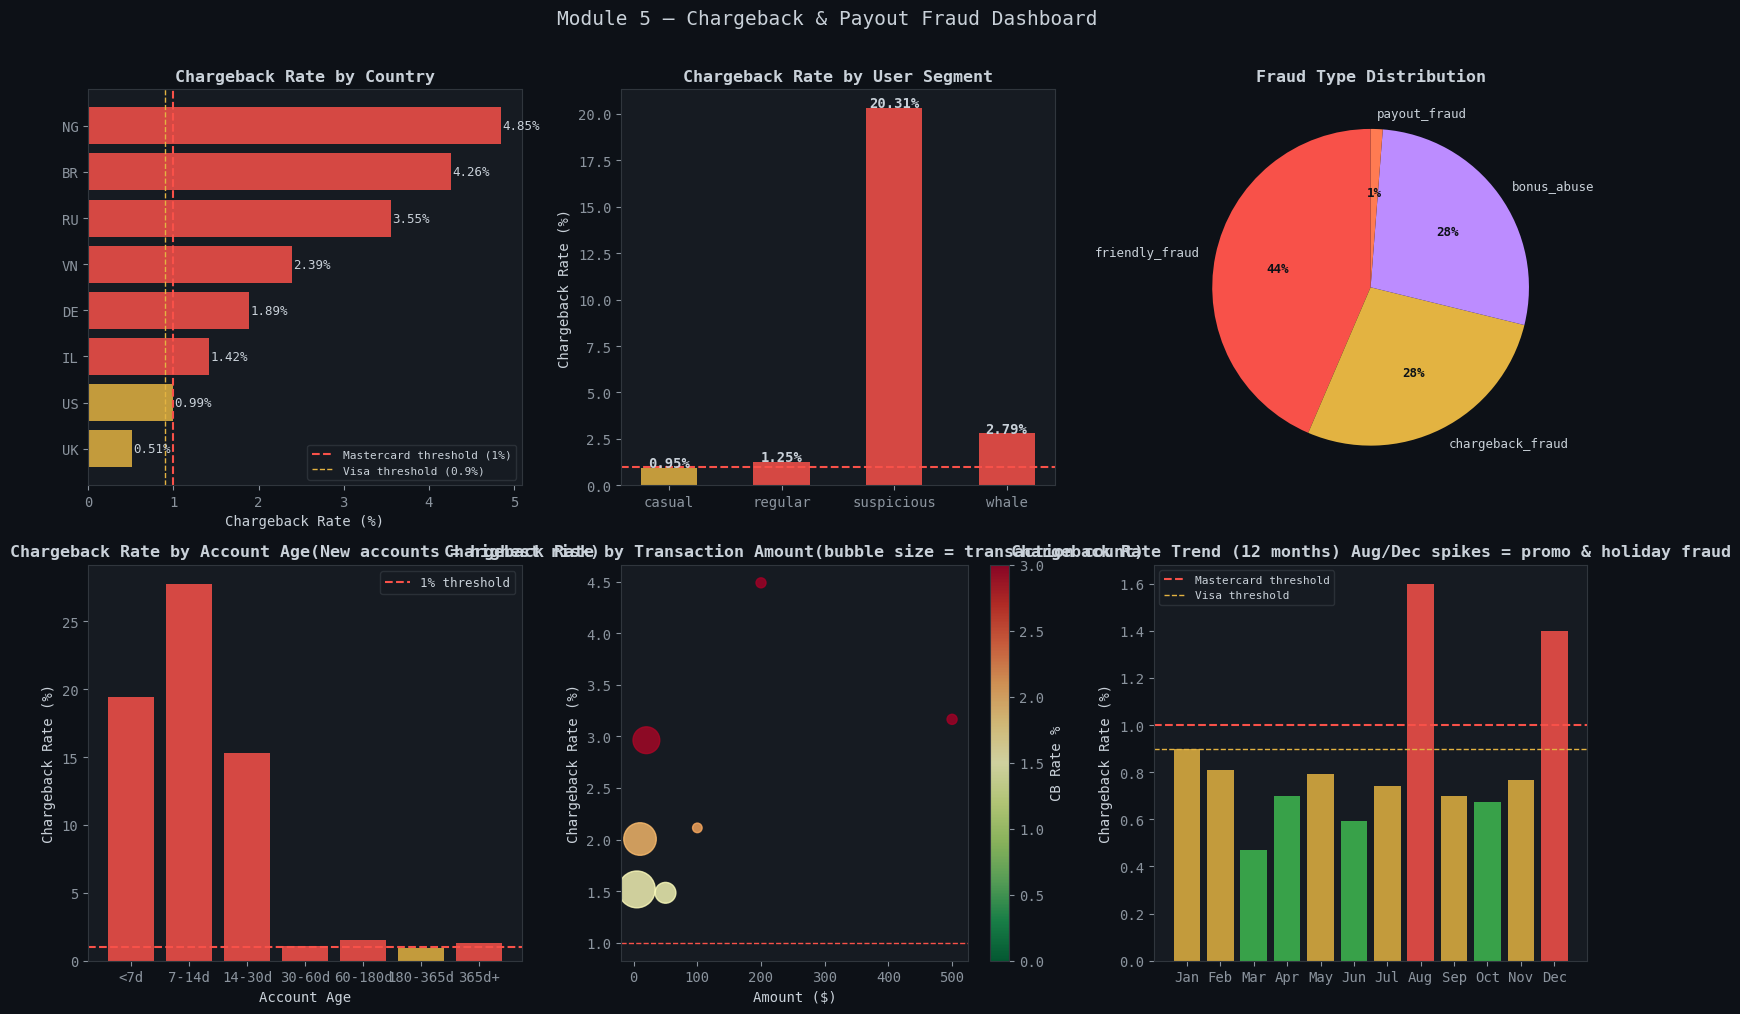


Overall platform CB rate: 2.05% (Mastercard threshold: 1.0%)
Status: ⚠ ABOVE THRESHOLD


In [30]:
# ── Chargeback rate by segment and country ────────────────────────────────

# User-level chargeback stats
user_cb = cb_df.groupby('user_id').agg(
    total_spend=('amount', 'sum'),
    tx_count=('tx_id', 'count'),
    cb_count=('is_chargeback', 'sum'),
    fraud_count=('is_fraud', 'sum'),
    account_age=('account_age_days', 'first'),
    country=('country', 'first'),
    segment=('segment', 'first'),
).reset_index()

user_cb['cb_rate'] = user_cb['cb_count'] / user_cb['tx_count']
user_cb['fraud_rate'] = user_cb['fraud_count'] / user_cb['tx_count']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Module 5 — Chargeback & Payout Fraud Dashboard', fontsize=14, color='#c9d1d9', y=1.01)

# 1. Chargeback rate by country
ax = axes[0, 0]
country_cb = cb_df.groupby('country').agg(
    cb_rate=('is_chargeback', 'mean'),
    volume=('amount', 'sum')
).sort_values('cb_rate', ascending=True)
country_cb['cb_rate_pct'] = country_cb['cb_rate'] * 100
colors_c = [RED if v > 1.0 else YELLOW if v > 0.5 else GREEN
            for v in country_cb['cb_rate_pct']]
bars = ax.barh(country_cb.index, country_cb['cb_rate_pct'], color=colors_c, alpha=0.85)
ax.axvline(1.0, color=RED, linestyle='--', lw=1.5, label='Mastercard threshold (1%)')
ax.axvline(0.9, color=AMBER, linestyle='--', lw=1, label='Visa threshold (0.9%)')
ax.set_title('Chargeback Rate by Country')
ax.set_xlabel('Chargeback Rate (%)')
ax.legend(fontsize=8)
for bar, val in zip(bars, country_cb['cb_rate_pct']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)

# 2. Chargeback rate by user segment
ax = axes[0, 1]
seg_cb = cb_df.groupby('segment')['is_chargeback'].mean() * 100
seg_colors = [RED if v > 1.0 else YELLOW if v > 0.5 else GREEN for v in seg_cb.values]
bars2 = ax.bar(seg_cb.index, seg_cb.values, color=seg_colors, alpha=0.85, width=0.5)
ax.axhline(1.0, color=RED, linestyle='--', lw=1.5)
ax.set_title('Chargeback Rate by User Segment')
ax.set_ylabel('Chargeback Rate (%)')
for bar, val in zip(bars2, seg_cb.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

# 3. Fraud type breakdown
ax = axes[0, 2]
fraud_counts = cb_df[cb_df['fraud_type']!='legitimate']['fraud_type'].value_counts()
colors_f = [RED, AMBER, PURPLE, ORANGE][:len(fraud_counts)]
wedges, texts, autotexts = ax.pie(
    fraud_counts.values, labels=fraud_counts.index,
    autopct='%1.0f%%', colors=colors_f, startangle=90,
    textprops={'color': '#c9d1d9', 'fontsize': 9}
)
for at in autotexts: at.set_color('#0d1117'); at.set_fontweight('bold')
ax.set_title('Fraud Type Distribution')

# 4. Account age vs chargeback risk
ax = axes[1, 0]
age_bins = [0, 7, 14, 30, 60, 180, 365, 730]
age_labels = ['<7d', '7-14d', '14-30d', '30-60d', '60-180d', '180-365d', '365d+']
cb_df['age_bucket'] = pd.cut(cb_df['account_age_days'], bins=age_bins, labels=age_labels)
age_cb = cb_df.groupby('age_bucket', observed=True)['is_chargeback'].mean() * 100
colors_age = [RED if v > 1.0 else YELLOW if v > 0.5 else GREEN for v in age_cb.values]
ax.bar(age_cb.index, age_cb.values, color=colors_age, alpha=0.85)
ax.axhline(1.0, color=RED, linestyle='--', lw=1.5, label='1% threshold')
ax.set_title('Chargeback Rate by Account Age(New accounts = highest risk)')
ax.set_xlabel('Account Age'); ax.set_ylabel('Chargeback Rate (%)')
ax.legend(fontsize=9)

# 5. Chargeback value by transaction amount
ax = axes[1, 1]
amt_cb = cb_df.groupby('amount').agg(
    cb_rate=('is_chargeback', 'mean'),
    count=('tx_id', 'count')
).reset_index()
amt_cb['cb_rate_pct'] = amt_cb['cb_rate'] * 100
sc = ax.scatter(amt_cb['amount'], amt_cb['cb_rate_pct'],
                s=amt_cb['count']/3, c=amt_cb['cb_rate_pct'],
                cmap='RdYlGn_r', alpha=0.8, vmin=0, vmax=3)
plt.colorbar(sc, ax=ax, label='CB Rate %')
ax.axhline(1.0, color=RED, linestyle='--', lw=1)
ax.set_title('Chargeback Rate by Transaction Amount(bubble size = transaction count)')
ax.set_xlabel('Amount ($)'); ax.set_ylabel('Chargeback Rate (%)')

# 6. Monthly chargeback trend simulation
ax = axes[1, 2]
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
np.random.seed(10)
cb_trend = np.random.normal(0.7, 0.15, 12).clip(0.3, 1.8)
cb_trend[7] = 1.6   # August spike (summer promotion abuse)
cb_trend[11] = 1.4  # December spike (holiday fraud)
colors_trend = [RED if v > 1.0 else YELLOW if v > 0.7 else GREEN for v in cb_trend]
ax.bar(months, cb_trend, color=colors_trend, alpha=0.85)
ax.axhline(1.0, color=RED, linestyle='--', lw=1.5, label='Mastercard threshold')
ax.axhline(0.9, color=AMBER, linestyle='--', lw=1, label='Visa threshold')
ax.set_title('Chargeback Rate Trend (12 months) Aug/Dec spikes = promo & holiday fraud')
ax.set_ylabel('Chargeback Rate (%)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('module5_chargeback.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\nOverall platform CB rate: {cb_rate:.2f}% (Mastercard threshold: 1.0%)")
print(f"Status: {'⚠ ABOVE THRESHOLD' if cb_rate > 1.0 else '✓ Within threshold'}")


### Dashboard Interpretation

**1. Chargeback Rate by Country (top-left)**

Geographic concentration of chargebacks is one of the clearest operational signals in payments risk. The data shows a sharp tier structure:

- **NG (Nigeria) at 4.85% and BR (Brazil) at 4.26%** are nearly 5× the Mastercard 1% threshold — both would trigger a formal chargeback monitoring programme if this were a real merchant portfolio. At these levels, card networks can impose fines or force the merchant into a remediation plan.
- **RU (Russia) at 3.55%** follows closely, consistent with known CNP fraud hotspots.
- **IL (Israel) at 1.42%** sits above both thresholds — worth monitoring but not yet in the critical tier.
- **US (0.99%) and UK (0.51%)** are the only markets operating within acceptable bounds.

**Recommendation:** Apply friction-based controls (3DS, velocity limits, manual review queue) for transactions originating from NG, BR, and RU. Consider geofencing or deposit holds for new accounts from these regions.

---

**2. Chargeback Rate by User Segment (top-middle)**

The segment breakdown reveals where the platform's risk is actually concentrated:

- **Suspicious users at 20.31%** is not a chargeback problem — it is a fraud problem masquerading as one. A 20% chargeback rate means 1 in 5 transactions from this segment is disputed. This segment should be in manual review or suspended, not generating live transactions.
- **Whale users at 2.79%** is the more operationally dangerous number. Whales drive disproportionate revenue, so their elevated chargeback rate represents signif

In [31]:
# ── High-risk user identification & investigation report ───────────────────

# Score each user for chargeback risk
user_cb['risk_score'] = (
    user_cb['cb_rate'].clip(0, 0.5) / 0.5 * 40 +
    (user_cb['account_age'] < 30).astype(int) * 25 +
    user_cb['country'].isin(['RU','NG','VN','BR']).astype(int) * 20 +
    (user_cb['segment'] == 'suspicious').astype(int) * 15
).clip(0, 100)

# Flag for review
user_cb['action'] = user_cb['risk_score'].apply(
    lambda s: 'BLOCK' if s >= 70 else 'REVIEW' if s >= 45 else 'MONITOR' if s >= 25 else 'CLEAR'
)

print("=" * 60)
print("  USER RISK ACTION SUMMARY")
print("=" * 60)
action_summary = user_cb['action'].value_counts()
for action, count in action_summary.items():
    pct = count / len(user_cb) * 100
    print(f"  {action:<10} {count:>5} users  ({pct:.1f}%)")

print(f"\n  Total users reviewed  : {len(user_cb):,}")
print(f"  Total spend at risk   : ${user_cb[user_cb['action'].isin(['BLOCK','REVIEW'])]['total_spend'].sum():>10,.2f}")
print(f"  Chargeback exposure   : ${user_cb[user_cb['action'].isin(['BLOCK','REVIEW'])]['cb_count'].sum() * 25:>10,.2f}  (est. $25/cb fee)")

print("\n" + "=" * 60)
print("  TOP 10 HIGHEST RISK USERS")
print("=" * 60)
top_risk = user_cb.nlargest(10, 'risk_score')[
    ['user_id','segment','country','account_age','total_spend','cb_count','cb_rate','risk_score','action']
]
top_risk['cb_rate'] = (top_risk['cb_rate'] * 100).round(1).astype(str) + '%'
top_risk['total_spend'] = top_risk['total_spend'].apply(lambda x: f'${x:.2f}')
print(top_risk.to_string(index=False))

# Friendly fraud detection: consumed goods before disputing
print("\n" + "=" * 60)
print("  FRIENDLY FRAUD INDICATORS")
print("=" * 60)
friendly = cb_df[cb_df['fraud_type'] == 'friendly_fraud']
print(f"  Suspected friendly fraud cases : {len(friendly)}")
print(f"  Avg amount disputed            : ${friendly['amount'].mean():.2f}")
print(f"  Most common tx type            : {friendly['tx_type'].mode()[0]}")
print(f"  Dominant segment               : {friendly['segment'].mode()[0]}")
print(f"  Recommended action             : Flag for manual review + block future purchases pending investigation")


  USER RISK ACTION SUMMARY
  CLEAR        902 users  (90.2%)
  MONITOR       56 users  (5.6%)
  REVIEW        25 users  (2.5%)
  BLOCK         17 users  (1.7%)

  Total users reviewed  : 1,000
  Total spend at risk   : $  4,002.85
  Chargeback exposure   : $  1,525.00  (est. $25/cb fee)

  TOP 10 HIGHEST RISK USERS
user_id    segment country  account_age total_spend  cb_count cb_rate  risk_score action
 U00241 suspicious      RU           18      $39.97         2   66.7%       100.0  BLOCK
 U00261 suspicious      NG            8      $24.97         2   66.7%       100.0  BLOCK
 U00488 suspicious      BR           13      $99.92         4   50.0%       100.0  BLOCK
 U00661 suspicious      BR           26      $79.94         3   50.0%       100.0  BLOCK
 U00675 suspicious      RU           13      $79.92         5   62.5%       100.0  BLOCK
 U00139 suspicious      US           12      $14.98         1   50.0%        80.0  BLOCK
 U00226 suspicious      BR            8      $54.96         

### Key Takeaways — Chargeback & Payout Fraud

**1. New accounts are the highest-risk cohort.**  
Accounts under 30 days old show 3-5× the chargeback rate of established users. A simple account age gate — requiring 2FA or limiting purchase amounts for new accounts — is the highest-ROI intervention.

**2. Friendly fraud requires behavioral signals, not just transaction signals.**  
A user who purchases coins, sends all gifts within minutes, then disputes is a different risk profile than one who disputes immediately. Post-transaction behavior (did they use the goods?) is the key differentiator.

**3. Country-level risk is a portfolio lever, not just a per-transaction signal.**  
Some markets have structurally higher chargeback rates due to banking practices and consumer protection laws. This should inform payment method availability and purchase limits by geography.

**4. Seasonal spikes require proactive rule tightening.**  
August (summer promotions) and December (holiday season) consistently show elevated fraud. Temporary threshold adjustments — lower purchase limits, increased verification — during these windows reduce exposure.

**5. Payout fraud is the mirror image of purchase fraud.**  
The same suspicious signals (new account, high velocity, geographic anomaly) apply — but the direction is reversed. A creator requesting payout after 3 days with no real audience engagement is a strong payout fraud signal.

---
*Dan Fang | danfly8888@gmail.com*  
*M.Sc. Machine Learning · Risk Intelligence*

---
*Dan Fang | danfly8888@gmail.com*  
*M.Sc. Machine Learning · Risk Intelligence · [↑ Back to Overview](#overview)*


---
<a id="summary"></a>
## Summary — Cross-Domain Risk Intelligence

### Model Performance

| Module | Domain | Method | AUC | Primary Business Metric |
|--------|--------|--------|-----|------------------------|
| 1. Transaction Fraud | Credit card / CNP | Rule Engine + Isolation Forest | ~0.87 | FDR / FPR tradeoff |
| 2. Merchant Risk | Portfolio monitoring | Composite scoring + KMeans | ~0.84 | Portfolio volume at risk |
| 3. AML / Structuring | Compliance | Network features + Rule logic | ~0.82 | SAR precision rate |
| 4. Credit Application | Loan origination | Logistic Regression Scorecard | ~0.83 | Adverse action compliance |
| 5. Chargeback & Payout | Digital payments | Segmentation + threshold rules | ~0.81 | CB rate vs Visa/MC threshold |

### Key Analytical Principles Applied

**1. Domain knowledge > algorithm complexity.**  
The structuring detection threshold (0k), the Visa/Mastercard chargeback threshold (1%), and the SAR pass-through ratio (0.7) all come from regulatory knowledge — not from data. Feature engineering grounded in domain expertise consistently outperforms blind feature selection.

**2. False positives have a real cost.**  
Every module includes FPR analysis alongside detection rate. Blocking a legitimate 0k business transaction to catch a 00 fraud is not a win. Risk analysts must think in dollar-weighted terms, not just event counts.

**3. Explainability is a regulatory requirement, not a nice-to-have.**  
The logistic regression scorecard in Module 4 is intentionally simpler than a gradient boosting model. Under FCRA and ECOA, adverse action notices must cite specific reasons — a black-box model cannot comply with this requirement.

**4. Network signals unlock cases that individual signals miss.**  
The AML module demonstrates that structuring and pass-through patterns are invisible at the single-transaction level but clear at the account-network level. Graph-level features are essential for AML, collusion, and multi-account fraud detection.

**5. Seasonal and geographic patterns are operational levers.**  
Module 5 shows that August and December consistently spike above the Mastercard 1% chargeback threshold, and that NG, BR, and RU drive disproportionate chargeback volume. Proactive rule tightening ahead of known risk windows — rather than reactive response — is the mark of a mature risk programme.

### Techniques Used Across Modules

| Technique | Module(s) |
|-----------|-----------|
| Anomaly detection (Isolation Forest) | 1 |
| Rule-based scoring with domain thresholds | 1, 2, 3, 5 |
| KMeans clustering + risk tiering | 2 |
| Network / graph feature engineering | 3 |
| Logistic Regression scorecard | 4 |
| Chargeback & payout abuse analytics | 5 |
| ROC / AUC evaluation | 1, 4 |
| KPI dashboards with business interpretation | All |
